# 1. Quais são as tendências de vendas ao longo do tempo?
    - Como as vendas variam ao longo dos meses e anos?
    - Existem sazonalidades que podem ser exploradas para campanhas de marketing?
# 2. Qual é o perfil dos clientes?
    - Qual é a distribuição de idades dos cleintes?
    - Como as vendas variam entre diferentes grupos etários e gêneros?
# 3. Quais são os produtos mais vendidos?
    - Quais categorias e subcategorias de produtos são mais populares?
    - Como a demanda por diferentes produtos varias ao longo do tempo?
# 4. Análise Geográfica
    - Quais são os principais mercados (países e estados) em termos de vendas?
    - Existe potêncial para expansão em regiões repecíficas?
# 5. Análise de Margem de Lucro
    - Quais produtos ou categorias têm a maior margem de lucro?
    - Como otimizar o mix de produtos para maximizar a lucratividade?
# 6. Comportamento de Compra dos Clientes
    - Qual é  a frequência de compra dos clientes?
    - Existem clientes recorrentes e qual é o seu impacto nas vendas totais?
# 7. Eficiência de Custos
    - Qual é a relação entre o custo unitário e o preço unitário dos produtos?
    - Existem oportunidades para reduzir os custos e aumentar a margem de lucro?

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
df = pd.read_csv("Sales.csv")
df.info() #DataFrame não possui valores nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost              113036 non-null  int

In [13]:
#Colocando todos as colunas para letras minusculas
df.columns = [x.lower() for x in df.columns]
#Colocando a coluna date para datetime
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              113036 non-null  datetime64[ns]
 1   day               113036 non-null  int64         
 2   month             113036 non-null  object        
 3   year              113036 non-null  int64         
 4   customer_age      113036 non-null  int64         
 5   age_group         113036 non-null  object        
 6   customer_gender   113036 non-null  object        
 7   country           113036 non-null  object        
 8   state             113036 non-null  object        
 9   product_category  113036 non-null  object        
 10  sub_category      113036 non-null  object        
 11  product           113036 non-null  object        
 12  order_quantity    113036 non-null  int64         
 13  unit_cost         113036 non-null  int64         
 14  unit

In [ ]:
# 1) Quantidade total de vendas cada dia.
qtdd_total = df.groupby("date")[["order_quantity"]].sum() #Poderia tirar essa lista de listas para utilizar sem o squeeze()

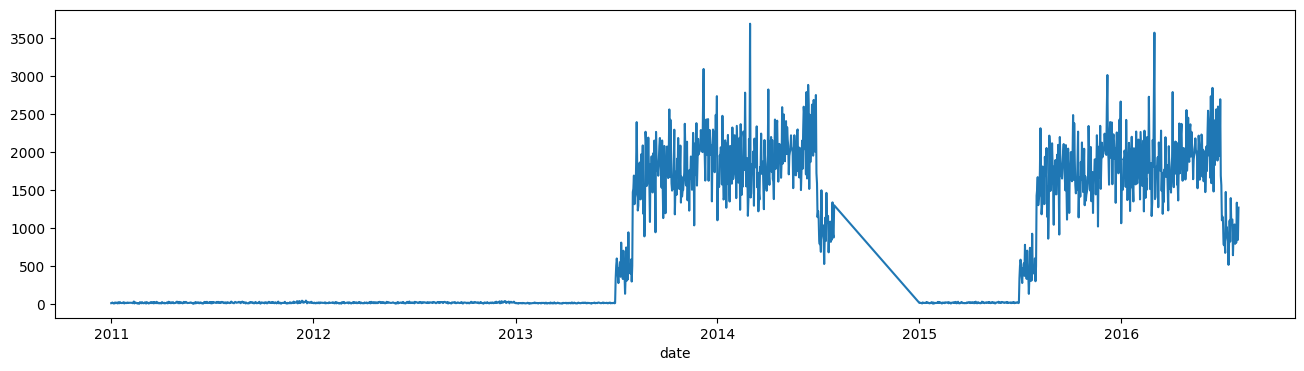

In [25]:
# Visualizar em termos de um gráfico para melhorar a visualizaçao em uma serie temporal
plt.figure(figsize=(16,4)) # Aumentar o gráfico
sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze()) #squeeze() - Deixa o array em forma unidimensional
plt.show()

Em meados de 2013 as vendas começaram a explodir, temos uma tendencia clara de alta até meados de 2014, em que as vendas caíram novamente até meados de 2015 que as vendas voltaram!
Como a escala grande de 5 anos tivemos muito mais vendas em alguns anos que outros, isso faz com que a escala do eixo y seja afetada e quase nao conseguimos enxergar a dinamica de vendas nos anos iniciais.
* Isso é um bom motivo para visualizar ano a ano

In [26]:
qtdd_total

,order_quantity
date,
2011-01-01,8
2011-01-02,9
2011-01-03,17
2011-01-04,10
2011-01-05,5
...,...
2016-07-27,807
2016-07-28,1332
2016-07-29,895


Para evitar oscilações muito grande: Aplica uma determinada janela de tempo e agrega as informações dentro dessa janela com a funçao de agregaçao mean()
* Deixar ela mais "suave"
* Quanto maior a quantidade de dias, maior a janela, mais suave

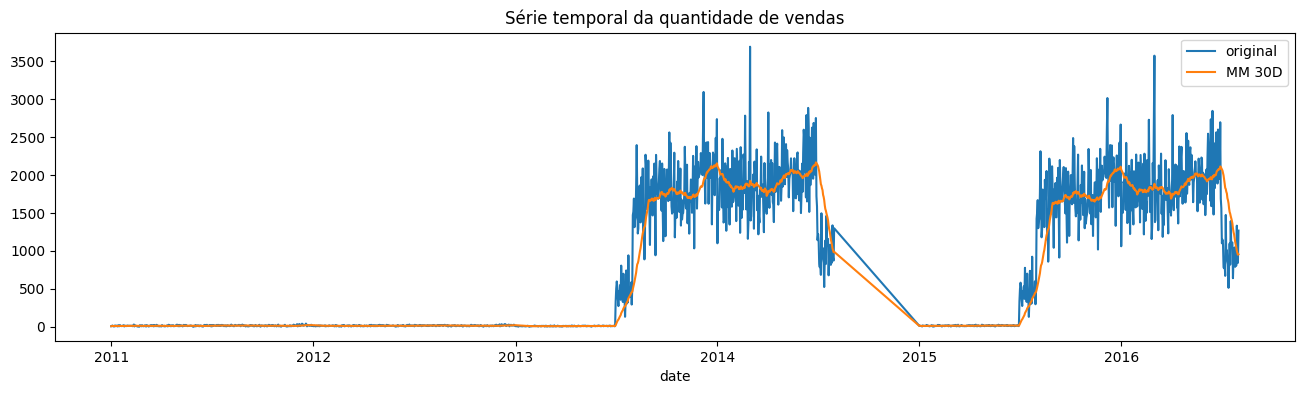

In [ ]:
# Rolling - O indice precisa ser datetime para ele funcionar de maneira simples.
qtdd_total_30d = qtdd_total.rolling(window = "30D").mean()
qtdd_total_3d = qtdd_total.rolling(window = "3D").mean() #Criar uma janela de 3 dias e ir deslizando ela pelos dados e calculando a media desses valores e colocando dentro de cada celula 

plt.figure(figsize=(16,4))
plt.title("Série temporal da quantidade de vendas")

sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze(), label = "original")
#sns.lineplot(x = qtdd_total_3d.index, y = qtdd_total_3d.values.squeeze(), label = "MM 3D")
sns.lineplot(x = qtdd_total_30d.index, y = qtdd_total_30d.values.squeeze(), label = "MM 30D")

plt.show()

* Com a janela de 3 dias não fica uma visualizaçao muito boa
* Com a janela de 30 dias é possível observar de maneira muito mais clara como ficou essa oscilação esse padrão de vendas que subiu mes a mes, enxergar melhor as tendencias integrando todo o ruido.
* Fica evidente que o periodo de julho de 2013 até julho de 2014 é muito parecido com julho de 2015 até julho de 2016.
* Podem ser dados "criados" apenas copiados

Mas ainda não é possivel visualizar a evolução de vendas nos primeiros 2 anos e meio, por isso irei visualizar essa série ano a ano.

In [43]:
for ano in df["year"].sort_values().unique():
    print(ano)

2011
2012
2013
2014
2015
2016


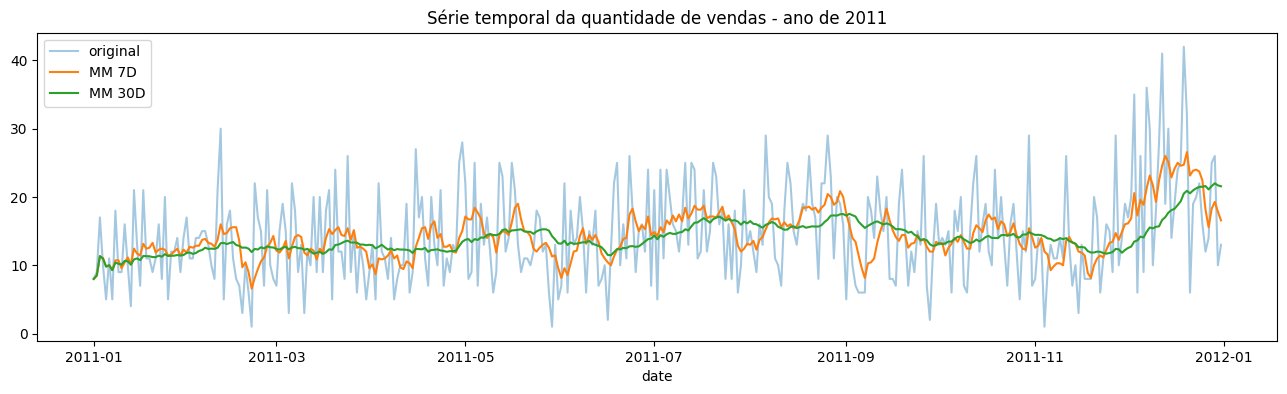

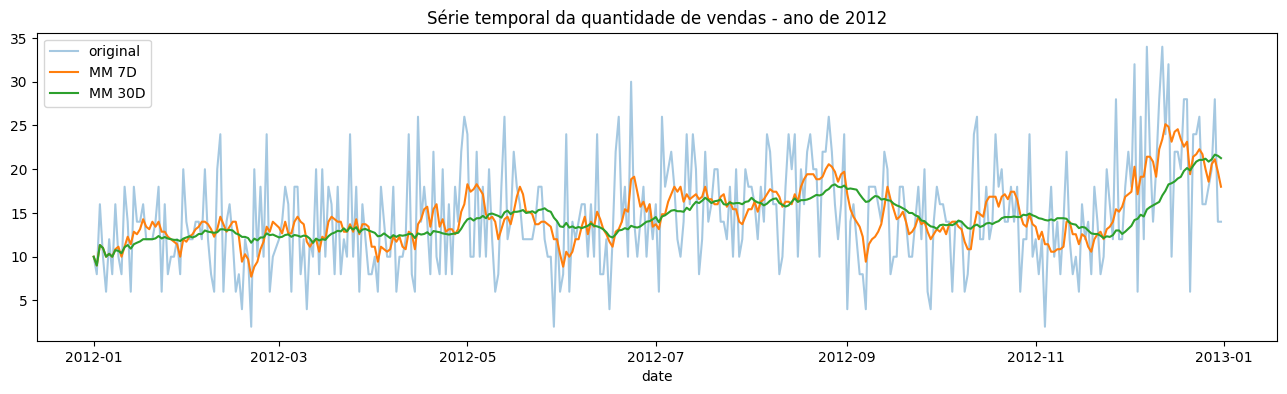

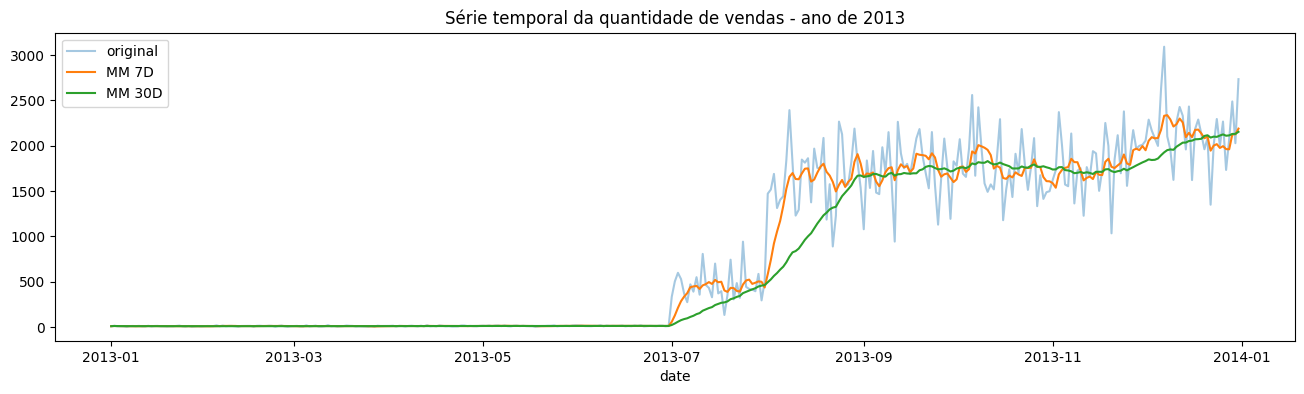

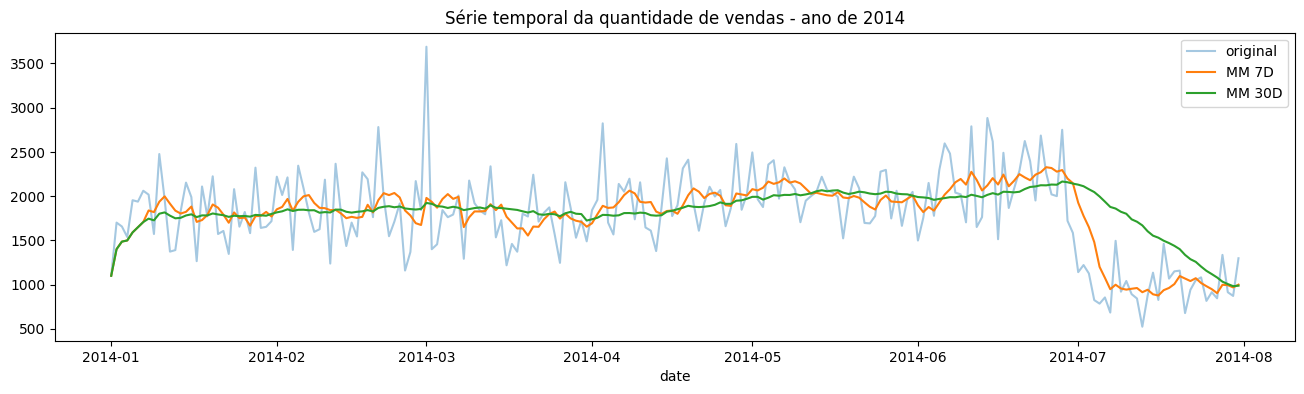

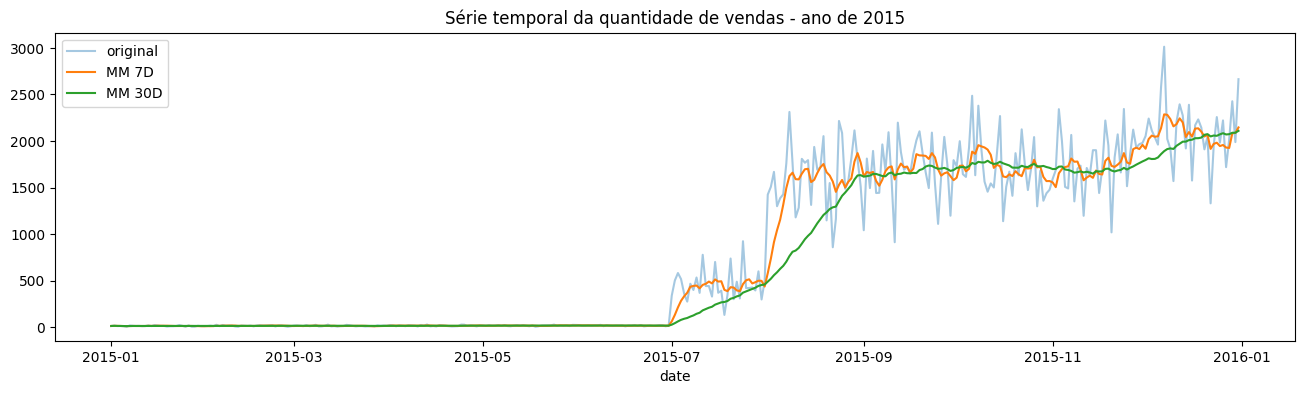

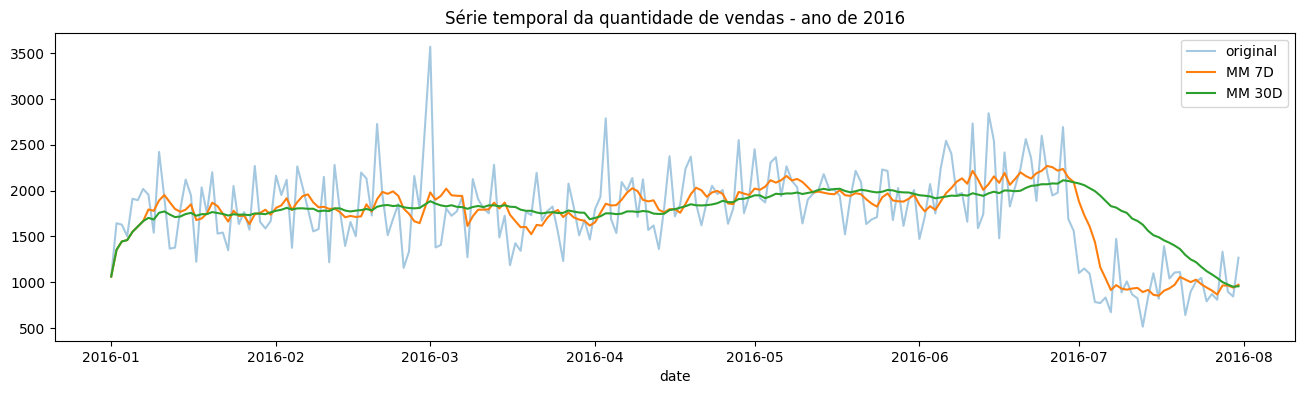

In [44]:
#Plotar somente os periodos necessários
for ano in df["year"].sort_values().unique():
    df_ano = df.query(f"year == {ano}")
    qtdd_total = df_ano.groupby("date")[["order_quantity"]].sum()

    qtdd_total_30d = qtdd_total.rolling(window = "30D").mean()
    qtdd_total_7d = qtdd_total.rolling(window = "7D").mean() #Criar uma janela de 3 dias e ir deslizando ela pelos dados e calculando a media desses valores e colocando dentro de cada celula 

    plt.figure(figsize=(16,4))
    plt.title(f"Série temporal da quantidade de vendas - ano de {ano}")

    sns.lineplot(x = qtdd_total.index, y = qtdd_total.values.squeeze(), label = "original", alpha =0.4) #Deixar mais transparente)
    sns.lineplot(x = qtdd_total_7d.index, y = qtdd_total_7d.values.squeeze(), label = "MM 7D")
    sns.lineplot(x = qtdd_total_30d.index, y = qtdd_total_30d.values.squeeze(), label = "MM 30D")

* Olhando para os gráficos 2011 e 2012 são muito parecidos temos um perfil muito claro dessa evolução, não são exatamente igual, percebe-se que em janeiro de 2012 teve um pico de vendas um pouco maior, dado que a média movel de uma semana tá um pouco mais distânciada da media móvel mensal, embora as quantidades exatamente não seja as mesmas tivemos um perfil muito parecido, com a media movel semanal um pouco a cima da mensal. O padrão de como as vendas funcionaram nesses dois anos, é muito parecido ficou estagnado e ao final deu uma leve subida.
* Já em 2013 acontece algo interessante, podemos observar que a partir de julho temos uma subida de vendas considerável, as vendas chegam perto de 3000 nesse período, aconteceu alguam estratégia, alguma mudança, o ideal é conversar com a área de negócio para entender o que aconteceu nesse período. Continua essa tendência de crescimento até setembro, depois ele vai estagnando, mas tem uma leve tendência de alta.
* Quando vamos para 2014 continua alta a taxa de vendas, não em 3000, mas proximo de 2000, teve uma pequena baixa, mas se manteve estável até julho, começou a cair novamente e vai vertiginosamente, os gráficos estavam até 2014 do inicio até o final, mas em 2014 temos dados somente até agosto, depois desse periodo só tem dados até inicio de 2015, temos um buraco na série, ou seja, não temos dados nesse período. Ex: a loja ficou fora do ar, teve algum erro na contabilização, entre outros.
* Em 2015 voltou as vendas lá embaixo, uma hipotese clara é que a loja ficou fora do ar nesse período, em 2015 quando volta já não estava tão quente a loja, levou novamente 6 meses para a tendência de alta parecida com 2013.
* E em 2016 uma tendência bem parecida com 2014 em julho de 2016 ele volta a cair até agosto.

In [45]:
#agrupar os dados pelo mes
df.groupby("month")[["order_quantity"]].sum()

,order_quantity
month,
April,118467
August,103119
December,133312
February,104717
January,110367
July,89787
June,128591
March,111085
May,125715


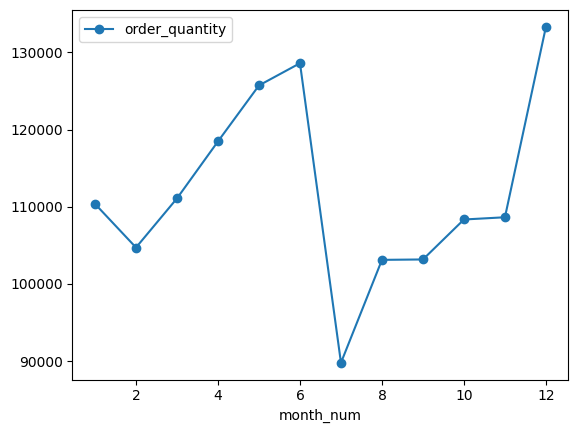

In [48]:
#Colocando os meses em ordem crescente
df["month_num"] = df["date"].apply(lambda x: x.month)
#agrupar os dados pelo mes
df.groupby("month_num")[["order_quantity"]].sum().plot(marker="o")
plt.show()

Quantidade total de vendas - ano de 2011


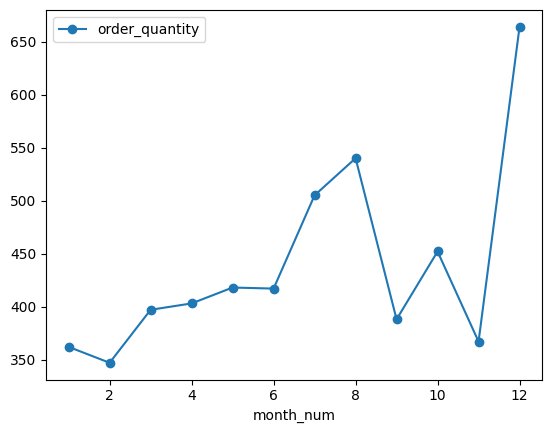

Quantidade total de vendas - ano de 2012


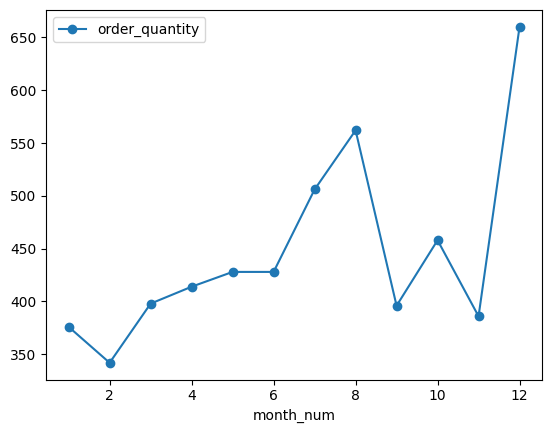

Quantidade total de vendas - ano de 2013


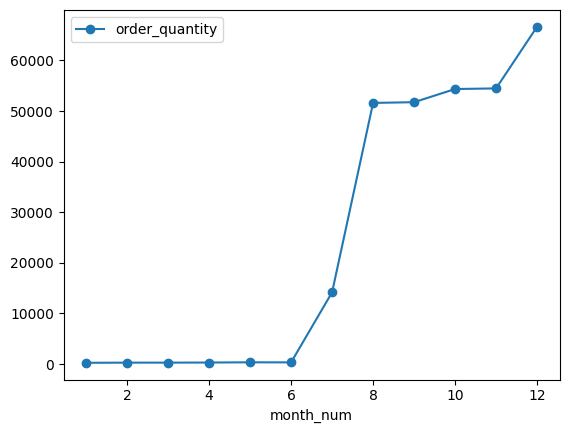

Quantidade total de vendas - ano de 2014


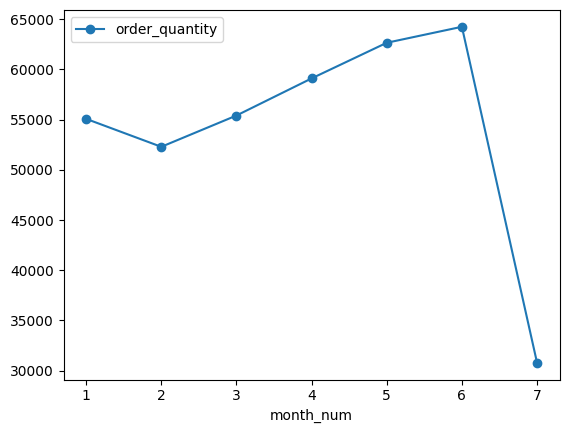

Quantidade total de vendas - ano de 2015


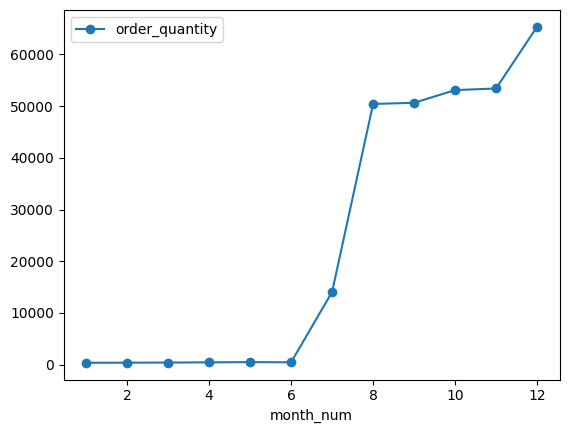

Quantidade total de vendas - ano de 2016


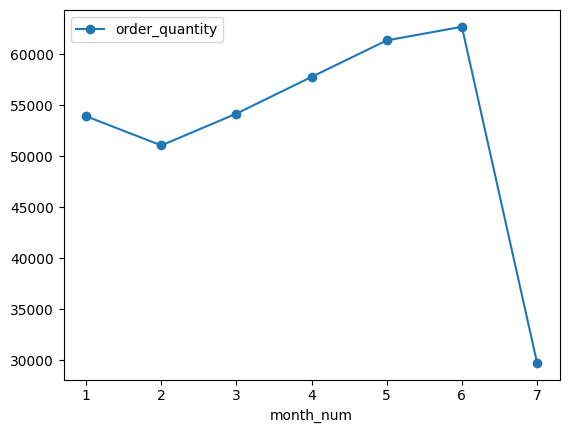

In [50]:
for ano in df["year"].sort_values().unique():

    df_ano = df.query(f"year == {ano}")

    print(f"Quantidade total de vendas - ano de {ano}")
    df_ano.groupby("month_num")[["order_quantity"]].sum().plot(marker="o")
    plt.show()